<center>

# Universidad nacional Autónoma de México
# 
# Facultad de Ingeniería
#
## Robótica
#
## Segundo parcial
#
## Profesor: Erick Peña Medina

## Alumna: López González Pamela Citlali Atletl

## No. de cuenta:
## 316040518


# Índice

1.	Introducción
#
2.	Objetivo
#
3.	Desarrollo
#
*   3.1. Modelado matemático y simulación en Matlab

    * 3.1.1 Definición del lugar geométrico de la trayectoria

    * 3.1.2 Planteamiento de la cinemática inversa

    * 3.1.3 Evaluación dinámica y estimación de potencia mecánica

*   3.2. Implementación de control en el entorno ROS 2

    * 3.2.1. Configuración del entorno de simulación (Gazebo y URDF)

    * 3.2.2. Arquitectura de control mediante nodos de ROS 2

    * 3.2.3. Sincronización entre Matlab y ROS 2

    * 3.2.4. Diagnóstico y comunicación de tópicos
    
4.	Resultados

* 4.1. Matlab

* 4.2. Robot 
#
5.	Conclusiones
# 
6.	Referncias


# 1. Introducción

En el presente proyecto se evaluaron y diseñron las capacidades cinemáticas, dinámicas y de potencia del robot SCARA (Selective Compliance Assembly Robot Arm) durante la ejecución de una tarea de seguimiento de trayectoria en línea recta. Esta arquitectura robótica es una de las más utilizadas en la automatización industrial, especialmente en procesos de alta velocidad como el ensamblaje de precisión, empaque y manipulación de componentes electrónicos en el plano horizontal. 

La relevancia de analizar dicho robot radica en la necesidad de predecir con exactitud si los actuadores seleccionados son físicamente capaces de soportar las demandas operativas reales antes de su implementación en una línea de producción.

La automatización avanzada no solo incrementa la competitividad industrial de un país, sino que mitiga directamente los riesgos de accidentes laborales al delegar tareas repetitivas o de alta fatiga a sistemas mecánicos autónomos. Esto fomenta un cambio positivo en la estructura social del trabajo, permitiendo que los operarios humanos transicionen hacia roles de mayor valor añadido, tales como la supervisión de sistemas inteligentes, el mantenimiento especializado y la optimización de procesos basados en datos. En el entorno económico actual, la capacidad de evaluar analíticamente un robot asegura que las inversiones tecnológicas de las empresas sean viables, eficientes y adaptables a las fluctuantes demandas del mercado internacional.

En este proyecto, la cinemática inversa permite transformar las coordenadas cartesianas de la línea recta propuesta en los perfiles de posición angular requeridos por las juntas del robot, asegurando un movimiento fluido y libre de singularidades o valores matemáticos imaginarios que imposibiliten la operación. Para realizar un diagnóstico cualitativo de esta agilidad cinemática en el espacio de trabajo, se incorpora el cálculo del Índice de Manipulabilidad, una herramienta matemática fundamental para determinar qué tan cerca se encuentra el manipulador de perder un grado de libertad durante su recorrido.

Por su parte, el modelo dinámico describe la interacción de las fuerzas inerciales, centrífugas y de Coriolis que actúan sobre la estructura molecular del brazo. A partir de este modelo, se determinan con precisión los vectores de velocidad y par (torque) que deben cubrir los motores en cada instante de tiempo. La integración de estos perfiles dinámicos permite estimar la potencia mecánica instantánea requerida por cada actuador y la potencia total consumida por el robot. Este análisis energético es bastante importante en la era de la Industria 4.0, donde la eficiencia energética y el diseño óptimo de sistemas electromecánicos son pilares clave para la sostenibilidad y la manufactura inteligente.

El desarrollo de este proyecto está orientado a la evaluación integral de un robot, el cual requiere la sinergia de diversas disciplinas de la ingeniería mecatrónica, la física aplicada y las ciencias de la computación. Se debe tener un conocimiento en las siguientes áreas:

* Cinemática y Dinámica de Robots: Para modelar geométricamente el espacio de trabajo, calcular matrices Jacobianas y formular las ecuaciones de movimiento que rigen el comportamiento del manipulador.

* Sistemas de Actuación y Potencia: Para interpretar las curvas de torque-velocidad de los motores, evaluar las capacidades de los actuadores comerciales y dimensionar los requerimientos energéticos del sistema.

* Cómputo Numérico y Simulación: Para utilizar herramientas avanzadas como MATLAB en el cálculo simbólico y numérico de las trayectorias, y entornos como ROS 2 y Gazebo para la validación y visualización tridimensional del sistema mecatrónico.

* Matemáticas e Ingeniería Aplicada: Para resolver sistemas de ecuaciones complejos, analizar funciones trigonométricas en el plano real y tomar decisiones de diseño basadas en criterios científicos y técnicos.

# 2. Objetivo

Evaluar las capacidades cinemáticas y dinámicas de un robot mediante el índice de manipulabilidad y las gráficas de potencia y determinar las características cinemáticas, dinámicas y de potencia de los actuadores del robot.

# 3. Desarrollo

### 3.1. Modelado matemático y simulación en Matlab

En esta sección se plantea el soporte matemático y geométrico utilizado para resolver la cinemática inversa del robot SCARA de 3 grados de libertad (GDL), así como el cálculo de las variables dinámicas de los actuadores necesarios para realizar la tarea de seguimiento de trayectoria lineal propuesta.
    
##### 3.1.1 Definición del lugar geométrico de la trayectoria

El trayecto del robot debe ser en línea recta manteniendo constante la coordenada en X y desplazándose suavemente sobre el eje Y. Las poses de inicio y fin para la tarea se definieron formalmente como:

* Pose inicial: x_in = 0.6; y_in = -0.2; theta_in = 0;

* Pose final: x_fin = 0.6; y_fin = 0; theta_fin = 0;

Los parámetros dimensionales asignados a los eslabones del brazo robótico para garantizar que toda la trayectoria se encuentre contenida de manera segura dentro de su espacio de trabajo real son:

* L1 = 0.5; Longitud del primer eslabón
* L2 = 0.5; Longitud del segundo eslabón
* L3 = 0.3; Longitud del tercer eslabón


    
##### 3.1.2 Planteamiento de la cinemática inversa

Para que el robot siga la línea recta cartesiana, es necesario mapear cada punto de la trayectoria al espacio de las articulaciones (θ1​,θ2​,θ3​). Primero se desacopla el efecto del tercer eslabón (L3​) para hallar la posición teórica de la articulación del "codo" (x3​,y3​) a partir de la orientación del efector final (θ_in​):

Inicial:

* x_3 = x_in - L3*cos(theta_in)

* y_3 = y_in - L3*sin(theta_in)

Final:

* x_3 = x_fin - L3*cos(theta_fin)
* y_3 = y_fin - L3*sin(theta_fin)

Aplicando el teorema del coseno sobre el triángulo formado por los eslabones L1​ y L2​, se determina el ángulo de la segunda articulación:

Inicial:
* 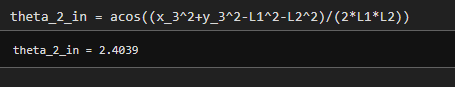

Final:

* 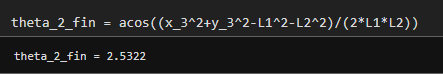

Obteniendo para la postura inicial un valor real y físicamente alcanzable.

El ángulo de la primera articulación (θ1​) se deduce mediante la diferencia geométrica de los componentes trigonométricos del brazo :

Inicial:

* 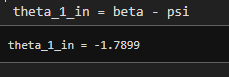

Final :

* 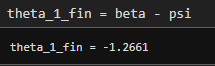

Finalmente, dado que la orientación total de la trayectoria final en el plano horizontal está definida por la suma algebraica de las orientaciones sucesivas de los eslabones, el ángulo de la tercera articulación (θ3​) se determina de manera directa mediante el principio de acoplamiento angular:

Inicial:

* 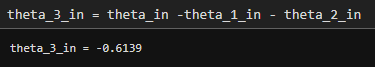

Final:

* 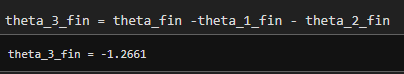

##### 3.1.3 Evaluación dinámica y estimación de potencia mecánica

A partir de la planeación de trayectorias en el espacio articular,se obtuvieron de manera continua los perfiles temporales de posición, velocidad y aceleración para cada una de las juntas del robot. 

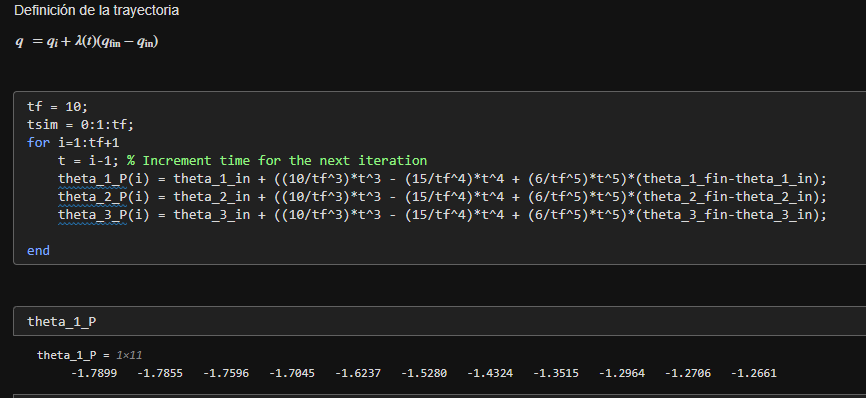

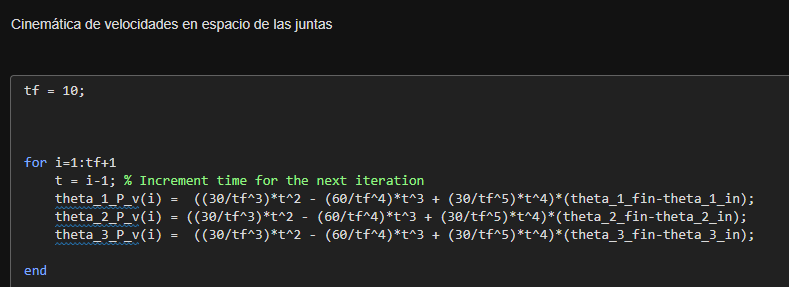

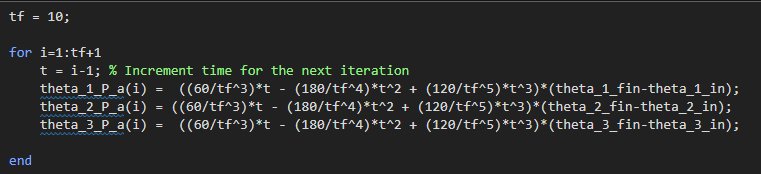



Estos vectores de estado sirvieron como datos de entrada para la evaluación del modelo dinámico inverso del manipulador SCARA.

Para resolver las ecuaciones de movimiento derivadas mediante Euler-Lagrange se ejecuta una serie de sustituciones algebraicas repetitivas denotadas como variables de optimización σ1​ hasta σ19​. 


$\begin{array}{l}
\left(\begin{array}{c}
{\ddot{\theta} }_{O,1} \,{\left(\frac{\cos \left(\theta_{1,2} \right)}{4}+\frac{{\sigma_{12} }^2 }{2}+\frac{{\sigma_{14} }^2 }{2}+\frac{27}{8}\right)}-{\dot{\theta} }_{2,3} \,{\left(\frac{\sigma_{18} \,\sigma_{10} }{16}-\frac{\sigma_{16} \,\sigma_{11} }{16}+\frac{\sigma_{12} \,\sigma_4 }{2}-\frac{\sigma_5 \,\sigma_{14} }{2}\right)}+{\ddot{\theta} }_{1,2} \,\sigma_3 +{\ddot{\theta} }_{2,3} \,\sigma_6 -{\dot{\theta} }_{1,2} \,{\left(\sigma_8 -\frac{\sigma_{14} \,\sigma_2 }{2}+\frac{\sigma_1 \,\sigma_{12} }{2}-\sigma_9 +\frac{{\dot{\theta} }_{1,2} \,\sin \left(\theta_{1,2} \right)}{8}+\frac{{\dot{\theta} }_{O,1} \,\sin \left(\theta_{1,2} \right)}{4}\right)}\\
\frac{{{\dot{\theta} }_{O,1} }^2 \,\sin \left(\theta_{1,2} \right)}{8}-{\dot{\theta} }_{2,3} \,{\left(\frac{\sigma_{18} \,\sigma_{10} }{16}-\frac{{\left(\frac{\sigma_{18} }{8}+\sigma_{19} \right)}\,\sigma_5 }{2}+\frac{{\left(\frac{\sigma_{16} }{8}+\sigma_{17} \right)}\,\sigma_4 }{2}-\frac{\sigma_{16} \,\sigma_{11} }{16}\right)}+{\ddot{\theta} }_{2,3} \,\sigma_7 +\frac{\sigma_{10} \,\sigma_1 }{2}+{\ddot{\theta} }_{O,1} \,\sigma_3 -\frac{\sigma_{11} \,\sigma_2 }{2}+{\ddot{\theta} }_{1,2} \,{\left(\frac{{{\left(\frac{\sigma_{16} }{8}+\sigma_{17} \right)}}^2 }{2}+\frac{{{\left(\frac{\sigma_{18} }{8}+\sigma_{19} \right)}}^2 }{2}+\frac{33}{16}\right)}-{\dot{\theta} }_{1,2} \,{\left(\frac{{\left(\frac{\sigma_{16} }{8}+\sigma_{17} \right)}\,\sigma_1 }{2}-\frac{{\left(\frac{\sigma_{18} }{8}+\sigma_{19} \right)}\,\sigma_2 }{2}+\sigma_8 -\sigma_9 +\frac{{\dot{\theta} }_{O,1} \,\sin \left(\theta_{1,2} \right)}{8}\right)}+\frac{{\dot{\theta} }_{1,2} \,{\dot{\theta} }_{O,1} \,\sin \left(\theta_{1,2} \right)}{8}\\
{\ddot{\theta} }_{2,3} \,{\left(\frac{{\sigma_{16} }^2 }{128}+\frac{{\sigma_{18} }^2 }{128}+1\right)}-\frac{\sigma_5 \,\sigma_{11} }{2}+{\ddot{\theta} }_{1,2} \,\sigma_7 -{\dot{\theta} }_{2,3} \,{\left(\frac{\sigma_{18} \,\sigma_{10} }{16}-\frac{\sigma_{18} \,\sigma_5 }{16}-\frac{\sigma_{16} \,\sigma_{11} }{16}+\frac{\sigma_{16} \,\sigma_4 }{16}\right)}+{\dot{\theta} }_{1,2} \,{\left(\frac{\sigma_{18} \,\sigma_2 }{16}-\frac{\sigma_{18} \,\sigma_{10} }{16}-\frac{\sigma_{16} \,\sigma_1 }{16}+\frac{\sigma_{16} \,\sigma_{11} }{16}\right)}+{\ddot{\theta} }_{O,1} \,\sigma_6 +\frac{\sigma_{10} \,\sigma_4 }{2}
\end{array}\right)\\
\mathrm{}\\
\mathrm{where}\\
\mathrm{}\\
\mathrm{\ \ }\sigma_1 =\frac{{\dot{\theta} }_{2,3} \,\sigma_{18} }{8}+\sigma_{15} +{\dot{\theta} }_{O,1} \,{\left(\frac{\sigma_{18} }{8}+\sigma_{19} \right)}\\
\mathrm{}\\
\mathrm{\ \ }\sigma_2 =\sigma_{13} +{\dot{\theta} }_{O,1} \,{\left(\frac{\sigma_{16} }{8}+\sigma_{17} \right)}+\frac{{\dot{\theta} }_{2,3} \,\sigma_{16} }{8}\\
\mathrm{}\\
\mathrm{\ \ }\sigma_3 =\frac{\cos \left(\theta_{1,2} \right)}{8}+\frac{{\left(\frac{\sigma_{16} }{8}+\sigma_{17} \right)}\,\sigma_{12} }{2}+\frac{{\left(\frac{\sigma_{18} }{8}+\sigma_{19} \right)}\,\sigma_{14} }{2}+\frac{33}{16}\\
\mathrm{}\\
\mathrm{\ \ }\sigma_4 =\frac{{\dot{\theta} }_{1,2} \,\sigma_{18} }{8}+\frac{{\dot{\theta} }_{2,3} \,\sigma_{18} }{8}+\frac{{\dot{\theta} }_{O,1} \,\sigma_{18} }{8}\\
\mathrm{}\\
\mathrm{\ \ }\sigma_5 =\frac{{\dot{\theta} }_{1,2} \,\sigma_{16} }{8}+\frac{{\dot{\theta} }_{2,3} \,\sigma_{16} }{8}+\frac{{\dot{\theta} }_{O,1} \,\sigma_{16} }{8}\\
\mathrm{}\\
\mathrm{\ \ }\sigma_6 =\frac{\sigma_{16} \,\sigma_{12} }{16}+\frac{\sigma_{18} \,\sigma_{14} }{16}+1\\
\mathrm{}\\
\mathrm{\ \ }\sigma_7 =\frac{\sigma_{16} \,{\left(\frac{\sigma_{16} }{8}+\sigma_{17} \right)}}{16}+\frac{\sigma_{18} \,{\left(\frac{\sigma_{18} }{8}+\sigma_{19} \right)}}{16}+1\\
\mathrm{}\\
\mathrm{\ \ }\sigma_8 =\frac{{\left(\frac{\sigma_{18} }{8}+\sigma_{19} \right)}\,\sigma_{10} }{2}\\
\mathrm{}\\
\mathrm{\ \ }\sigma_9 =\frac{{\left(\frac{\sigma_{16} }{8}+\sigma_{17} \right)}\,\sigma_{11} }{2}\\
\mathrm{}\\
\mathrm{\ \ }\sigma_{10} =\sigma_{13} +\frac{{\dot{\theta} }_{2,3} \,\sigma_{16} }{8}+{\dot{\theta} }_{O,1} \,\sigma_{12} \\
\mathrm{}\\
\mathrm{\ \ }\sigma_{11} =\frac{{\dot{\theta} }_{2,3} \,\sigma_{18} }{8}+{\dot{\theta} }_{O,1} \,\sigma_{14} +\sigma_{15} \\
\mathrm{}\\
\mathrm{\ \ }\sigma_{12} =\frac{\sigma_{16} }{8}+\sigma_{17} +\frac{\cos \left(\theta_{O,1} \right)}{2}\\
\mathrm{}\\
\mathrm{\ \ }\sigma_{13} ={\dot{\theta} }_{1,2} \,{\left(\frac{\sigma_{16} }{8}+\sigma_{17} \right)}\\
\mathrm{}\\
\mathrm{\ \ }\sigma_{14} =\frac{\sigma_{18} }{8}+\sigma_{19} +\frac{\sin \left(\theta_{O,1} \right)}{2}\\
\mathrm{}\\
\mathrm{\ \ }\sigma_{15} ={\dot{\theta} }_{1,2} \,{\left(\frac{\sigma_{18} }{8}+\sigma_{19} \right)}\\
\mathrm{}\\
\mathrm{\ \ }\sigma_{16} =\cos \left(\theta_{1,2} +\theta_{2,3} +\theta_{O,1} \right)\\
\mathrm{}\\
\mathrm{\ \ }\sigma_{17} =\frac{\cos \left(\theta_{1,2} +\theta_{O,1} \right)}{2}\\
\mathrm{}\\
\mathrm{\ \ }\sigma_{18} =\sin \left(\theta_{1,2} +\theta_{2,3} +\theta_{O,1} \right)\\
\mathrm{}\\
\mathrm{\ \ }\sigma_{19} =\frac{\sin \left(\theta_{1,2} +\theta_{O,1} \right)}{2}
\end{array}$

Estas variables agrupan las interacciones de las masas, inercias y efectos trigonométricos acoplados de los eslabones, permitiendo determinar analíticamente los perfiles de par o torque requeridos por cada actuador (τ1​,τ2​,τ3​) en cada instante del recorrido

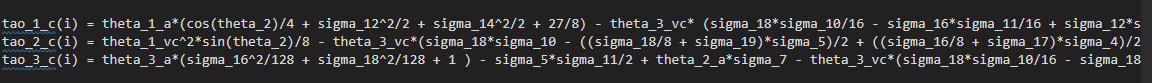

Una vez que los torques y las velocidades articulares están completamente determinados para cada paso de la simulación, se procede con la estimación de la energía del sistema. La potencia mecánica instantánea (Pi​) demandada por el motor de cada articulación de manera individual se calcula mediante el producto directo del valor absoluto de su torque por su velocidad angular correspondiente :

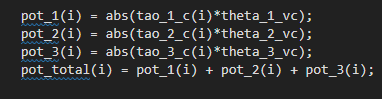

Para evaluar el consumo energético global del robot durante la tarea, se calcula la potencia mecánica total instantánea (P_total​) como la sumatoria algebraica de las contribuciones de potencia individuales

##### 3.2.1. Configuración del entorno de simulación (Gazebo y URDF)

La simulación del brazo robótico SCARA se estructuró bajo el paradigma de modelado de ROS 2, separando la descripción física de la lógica de ejecución

El robot fue definido mediante el formato Unified Robot Description Format (URDF), estructurado en el paquete scara_description. La configuración física se basa en una cadena cinemática de tres grados de libertad, compuesta por tres eslabones conectados mediante juntas de revolución:

* Cinemática: El modelo establece una base fija conectada a un eslabón principal (link_1), seguido por un eslabón secundario (link_2) y un eslabón terminal (link_3). Cada unión incluye parámetros de inercia y colisión, esenciales para que el motor de física de Gazebo calcule correctamente el comportamiento dinámico.

* Gestión de Límites: Para asegurar la integridad del movimiento, se definieron límites de carrera (limit) en cada articulación. Específicamente, en link_3_joint, se amplió el rango dinámico a [-4.0, 4.0] radianes, permitiendo al efector final alcanzar las configuraciones calculadas en el modelo matemático de Matlab sin incurrir en bloqueos por software.

La simulación física se realiza mediante el motor Gazebo. La integración del robot con el entorno virtual se logra a través del archivo scara_gz2.xacro, donde se inyectan los plugins necesarios:

* JointPositionController: Este sistema es el responsable de gestionar la entrada de comandos de posición (cmd_pos) para cada articulación, además se configuró con parámetros de ganancia Proporcional (p_gain), Integral (i_gain) y Derivativa (d_gain) para cada junta, asegurando un seguimiento de trayectoria suave y minimizando el error de estado estacionario.

* JointStatePublisher: Plugin dedicado a la retroalimentación del sistema, publicando en tiempo real el estado de las articulaciones (/joint_states), permitiendo la visualización precisa en RViz y facilitando la depuración del sistema de control.
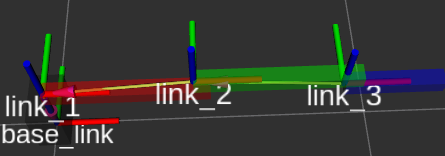


##### 3.2.2. Arquitectura de control mediante nodos de ROS 2

La estrategia de control para la ejecución de la trayectoria se implementó mediante un nodo de ROS 2 denominado tray_test, cuya lógica fue encapsulada en la clase TrayTestMatlab definida dentro del archivo fuente trajectory_test.py. Este nodo es el orquestador principal, encargado de traducir las coordenadas articulares calculadas en Matlab hacia los controladores de bajo nivel en Gazebo.

Los componentes arquitectonicos de dicho archivo son:

* Interface de Publicación: La clase TrayTestMatlab instancia tres publicadores de tipo std_msgs/msg/Float64, configurados específicamente para los tópicos /joint1/cmd_pos, /joint2/cmd_pos y /joint3/cmd_pos. Esta configuración permite una comunicación directa con los JointPositionControllers de Gazebo, enviando los comandos de posición de forma individual para cada eslabón.

* Telemetría y Diagnóstico: Se incluyó un publicador adicional de tipo Float64MultiArray en el tópico /scara_status. Este canal permite extraer y monitorear el vector de estado de las articulaciones en tiempo real, facilitando la validación comparativa entre la trayectoria deseada y el comportamiento del robot en la simulación.

* Lógica de Ejecución (Timer Callback): La ejecución de la trayectoria se maneja mediante un temporizador (create_timer) con una frecuencia de 2 Hz (periodo de 0.5 s), establecida para permitir la observación visual del movimiento articular durante la etapa de validación. Este bucle asegura que el nodo recorra de forma cíclica el arreglo de 11 puntos de trayectoria, garantizando una actualización constante del comando de posición.

Ahora, ewl flujo de proceso funcona de la siguiente forma: 

* Inicialización: El nodo carga en memoria los vectores pre-calculados de configuración articular ($q_1, q_2, q_3$).

* Ciclo de Actualización: A través de la función timer_callback, el nodo extrae el índice actual de la trayectoria.

* Envío de Comandos: Se publican los valores escalares a los tópicos de control, permitiendo que el motor de física de Gazebo resuelva la dinámica del movimiento.

* Retroalimentación: La telemetría capturada permite verificar que la secuencia se está procesando conforme a la lógica establecida.

##### 3.2.3. Sincronización entre Matlab y ROS 2

Dado que la trayectoria del brazo SCARA fue derivada mediante modelos de cinemática inversa en Matlab, el reto técnico consistió en transferir estas coordenadas articulares al entorno de simulación de ROS 2 sin comprometer la trayectoria y las físicas del modelo.

* Migración de datos: Los puntos de trayectoria obtenidos en Matlab fueron extraídos como vectores de datos, los cuales fueron integrados directamente en el archivo trajectory_test.py mediante arreglos de Python (q1, q2, q3). De esta manera se pueden cambiar los datos de manera sencilla o incluso aumentar el número de datos para el seguimiento de de la ruta.

* Normalización y coherencia: Se aseguró que los valores, originalmente calculados en radianes, fueran consistentes con los límites físicos definidos en el archivo URDF del robot. Este proceso de sincronización permite que el sistema de control de bajo nivel (el JointPositionController en Gazebo) interprete los comandos como una trayectoria continua y no como pasos discretos independientes, manteniendo la integridad del movimiento calculado.

* Ciclo de control: La sincronización se finaliza mediante el nodo tray_test, el cual procesa los arreglos de datos de forma sincronizada con la simulación. Al ejecutarse en un entorno de tiempo real, la transferencia de estos puntos asegura que el modelo virtual replique con alta fidelidad el comportamiento dinámico proyectado inicialmente en los estudios de Matlab.

##### 3.2.4. Diagnóstico y comunicación de tópicos

Dado que la integración de sistemas implica riesgos de desincronización o errores de comunicación en el middleware de ROS 2, se implementó un protocolo de validación:

* En la red de tópicos: Se utilizó el comando ros2 topic list para confirmar la existencia y disponibilidad de los tópicos /joint1/cmd_pos, /joint2/cmd_pos y /joint3/cmd_pos. Esta verificación inicial aseguró que los controladores definidos en el archivo de descripción (xacro) estuvieran correctamente vinculados al motor de física.

* Depuración de señales: Durante las pruebas de trayectoria, se utilizó ros2 topic echo para capturar en tiempo real los datos transmitidos por el nodo tray_test. Esto permitió realizar una comparación directa entre los valores de consigna y la respuesta del sistema.
 

# 4. Resultados

### 4.1. Matlab

Evolución de la configuración angular ($\theta_1, \theta_2, \theta_3$) en función del tiempo para los 11 puntos de la trayectoria calculada :

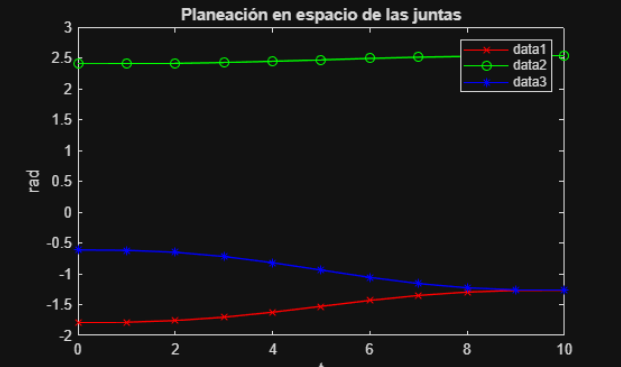

Representación de la trayectoria planeada proyectada en el espacio de trabajo, validando el desplazamiento del efector final:

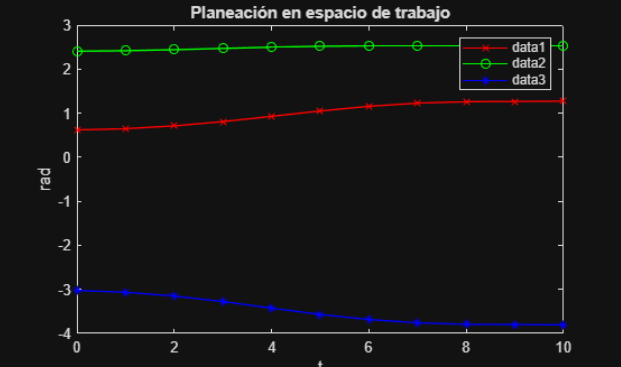

Perfil de velocidades angulares calculado para asegurar un movimiento suave y continuo, evitando cambios bruscos de aceleración.

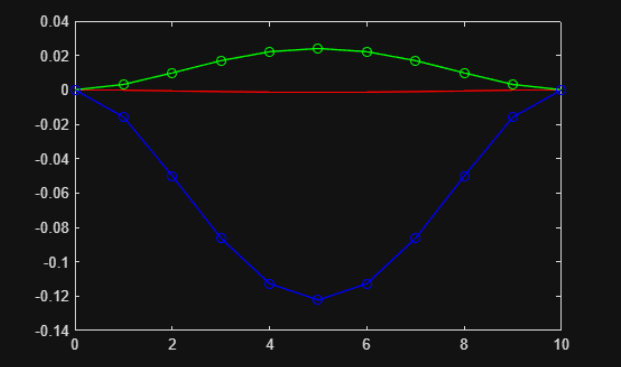

### 4.2. Robot

[![Simulación Robot SCARA 3R - Validación Dinámica](https://img.youtube.com/vi/Y_Wjx10M_NM/mqdefault.jpg)](https://www.youtube.com/watch?v=Y_Wjx10M_NM)

# 5. Conclusiones

La implementación del sistema de control para el robot SCARA de tres grados de libertad  me permitió entender la transición necesaria entre el análisis cinemático teórico y su ejecución práctica en un entorno de simulación.

por un lado la fase de validación matemática en Matlab expuso la existencia de configuraciones articulares con valores imaginarios. Estos resultados, lejos de ser errores computacionales, representan puntos físicamente inalcanzables fuera del espacio de trabajo del robot. Esto solo nos da una razón para realizar una verificación geométrica previa al cálculo de la cinemática inversa, asegurando que cualquier trayectoria planeada sea, ante todo, ejecutable dentro de los límites físicos del manipulador.

También se evidenció que la precisión del seguimiento de trayectorias está intrínsecamente ligada a la densidad de los puntos de referencia. Durante el desarrollo note que al trabajar con un conjunto reducido de datos —en este caso, 11 puntos—, una separación excesiva entre el punto inicial y el final provoca una distorsión geométrica, donde la interpolación lineal tiende a comportarse visualmente como una curva por la interpolación que hacen los motores de animación. Esta limitación denota que, aunque la inyección manual de valores en el nodo de control permite un seguimiento punto a punto, la linealidad perfecta de una trayectoria requiere una mayor densidad de puntos, un proceso que resulta complejo de implementar de forma manual y que sugiere la conveniencia de adoptar algoritmos de interpolación dinámica en futuras iteraciones.
 
Otro problema que se presentó y se solucionó en el desarrollo del robot es sobre la robustez de un sistema robótico, ya que este no depende exclusivamente de la lógica del algoritmo, sino de la coherencia entre el modelo físico y sus restricciones, es decir, durante las pruebas, se determinó que la falta de movimiento o el estado estático del robot en Gazebo y RViz no siempre responden a fallos en el código, sino a bloqueos de software originados por límites de articulación (lower y upper) configurados de manera restrictiva en el archivo URDF. La resolución de este bloqueo mediante el ajuste preciso de dichos parámetros fue el paso determinante para asegurar la continuidad del movimiento del efector final. 

Al final la simulación dinámica es una representación fidedigna del mundo físico únicamente cuando los límites definidos en la descripción del modelo se alinean estrictamente con las capacidades reales de los actuadores, consolidando así un flujo de trabajo de ingeniería donde el diagnóstico constante y la depuración del modelo físico son tan críticos como el desarrollo del propio nodo de control.

# 6. Referencias

[1] M. W. Spong, S. Hutchinson y M. Vidyasagar, Robot Modeling and Control. John Wiley & Sons, 2006. [En línea]. Disponible en: https://www.academia.edu/38555628/Robot_Modeling_and_Control_Subir_Kumar_Saha_pdf

[2] MATLAB Robot Control, “Robotics System Toolbox: Inverse Kinematics and Trajectory Planning,” MathWorks, 2026. [En línea]. Disponible en: https://es.mathworks.com/help/robotics/ug/inverse-kinematics-algorithms.html

[3] ROS 2 Documentation, “About ROS 2 - Hardware and Simulation integration,” Open Source Robotics Foundation, 2026. [En línea]. Disponible en: https://docs.ros.org/en/jazzy/index.html

[4] Sistemas Dinámicos y Control, “Jacobiano Analítico y Singularidades | Robot Planar de 2 GDL | Cinemática Diferencial,” YouTube, 06 de noviembre de 2022. [En línea]. Disponible en: https://www.youtube.com/watch?v=2_4grRMwYPo

[5] MATLAB Robot Control, “Manipulability of Robotic Manipulators - Robotics System Toolbox,” MathWorks, 2026. [En línea]. Disponible en: https://es.mathworks.com/help/robotics/ug/manipulability.html